
# 22 — The Boolean ring: monotone basis, visibility window

A dedicated illustration of the *ring over originals* design in
[`docs/BOOLRING.md`](../docs/BOOLRING.md) and of
[`crates/ewm-boolring/src/lib.rs`](../crates/ewm-boolring/src/lib.rs):
what `BoolWindow` does when it `push`es an original, slides the **visibility
window**, and evaluates a **compound** set with `residual` / `coordinates`
*without inserting it*.

It also answers one precise representation question:

> **Can an HLLSet produced by the HLLSet lattice operations (∪, ∩, \) be
> represented exactly as an XOR of ring basis HLLSets?**

Short answer, derived and measured below:

```text
ring   (GF(2) span) : Δ closed;  ∩, ∪, \ generally NOT closed
lattice (Boolean)   : ∩, ∪ closed; Δ = (A∪B) Δ (A∩B) derived

for A, B in the span S:
    A Δ B  ∈ S                        always
    A ∪ B  ∈ S   ⟺   A ∩ B ∈ S        (A∪B and A∩B are congruent mod S)
    A \ B  ∈ S   ⟺   A ∩ B ∈ S        (A\B and A∩B are congruent mod S)

the meet A ∩ B is the single obstruction:  A ∪ B = A Δ B Δ (A ∩ B),
A \ B = A Δ (A ∩ B), so all three compounds lie in one coset X + S.
Exact test for any set X:  X ∈ S  ⟺  coordinates(X) is not None
                                ⟺  residual(X) = ∅.
```

The notebook works on **real HLLSets**: the flat token → bit morphism is
reproduced bit-exactly in Python (`mmh3`, pinned against
`hllset-contracts/src/hashing.rs`), so the sets are subsets of the same
`32768`-bit plane the Rust code uses. The ring is a transparent
line-for-line mirror of the crate, so every GF(2) step is visible.


## §0 — Environment

The morphism is pinned by `hllset-contracts::hashing`:
`reg = hash & 1023`, `tz = trailing_zeros(hash >> 10)`, `bit = reg*32 + tz`,
with MurmurHash3 x64-128 (lower 64 bits). `mmh3.hash64` answers the pinned
test vector exactly.

In [1]:

import collections
import dataclasses
import itertools
import json
import pathlib
import random
import subprocess

import mmh3
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


def find_root(start):
    for anc in [start, *list(start.parents)[:4]]:
        for cand in [anc, *[p for p in anc.iterdir() if p.is_dir()]]:
            if (cand / "crates" / "ewm-boolring").exists():
                return cand
    return None


ROOT = find_root(pathlib.Path.cwd())
assert ROOT is not None, "run this notebook from the repo or its notebooks/ directory"
EWM_SCENE = ROOT / "target" / "debug" / "ewm-scene"

P, M, BITS_PER_REG = 10, 1024, 32
TOTAL_BITS = M * BITS_PER_REG

# hllset-contracts/src/hashing.rs, test murmur3_matches_python_mmh3_known_answers
assert mmh3.hash64(b"tid0", seed=0, signed=False)[0] == 2_892_634_914_804_110_692

print("repo      :", ROOT)
print(f"hllset    : P={P} M={M} plane={TOTAL_BITS} bits (mmh3 pinned OK)")
print("ewm-scene :", EWM_SCENE, "(present)" if EWM_SCENE.exists() else "(will build)")

repo      : /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine
hllset    : P=10 M=1024 plane=32768 bits (mmh3 pinned OK)
ewm-scene : /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene (present)



## §1 — GF(2) arithmetic on real HLLSets

`μ_flat` is the flat projection: each token inscribes one bit. Two token
collections therefore map to bitmasks whose union/intersection/difference is
bitwise OR/AND/AND-NOT, and whose **symmetric difference is GF(2) addition**.

The lattice is recovered from the ring by

```text
A ∪ B = A Δ B Δ (A ∩ B).
```

In [2]:

# ── μ_flat, exactly as Rust HLLSet::add_hash / from_tokens ──────────────────
def token_position(tok):
    h = mmh3.hash64(tok.encode(), seed=0, signed=False)[0]
    reg = h & (M - 1)
    rem = h >> P
    tz = 31 if rem == 0 else min((rem & -rem).bit_length() - 1, 31)
    return reg * BITS_PER_REG + tz


def hllset(tokens):
    """An HLLSet as a Python int bitmask over the 32768-bit plane."""
    m = 0
    for t in tokens:
        m |= 1 << token_position(t)
    return m


popcount = int.bit_count
union = lambda a, b: a | b
intersection = lambda a, b: a & b
difference = lambda a, b: a & ~b
symmetric_difference = lambda a, b: a ^ b


# ── Synthetic clip: 10 scenes x 10 frames, 200-token scene base + 56-token
#    per-frame drift (the docs/BOOLRING.md pseudo-clip shape). ──────────────
SCENES, FRAMES_PER_SCENE = 10, 10
BASE_TOKENS, DRIFT_TOKENS = 200, 56
TRUE_CUTS = [1 + s * FRAMES_PER_SCENE for s in range(1, SCENES)]  # 1-based

clip_tokens, clip_sets, clip_base = [], [], []
for s in range(SCENES):
    base = [f"s{s}_w{j}" for j in range(BASE_TOKENS)]
    for f in range(FRAMES_PER_SCENE):
        t = s * FRAMES_PER_SCENE + f
        toks = base + [f"d{t}_{j}" for j in range(DRIFT_TOKENS)]
        clip_tokens.append(toks)
        clip_sets.append(hllset(toks))
        clip_base.append(hllset(base))

print(f"clip: {len(clip_sets)} frames, {len(clip_tokens[0])} tokens/frame")
print("frame 1 popcount:", popcount(clip_sets[0]), "| frame 2:", popcount(clip_sets[1]))
print("1-based scene-cut starts:", TRUE_CUTS)

# ── The ring/lattice identity, checked on the real bitmasks ────────────────
A, B = clip_sets[0], clip_sets[1]
lhs = union(A, B)
rhs = symmetric_difference(symmetric_difference(A, B), intersection(A, B))
print("\nA ∪ B == A Δ B Δ (A ∩ B):", lhs == rhs)
print("|A|,|B|,|A∩B|,|A∪B|,|AΔB| =",
      popcount(A), popcount(B), popcount(intersection(A, B)),
      popcount(lhs), popcount(symmetric_difference(A, B)))
print("inclusion-exclusion: |A|+|B| = |A∩B|+|A∪B|:",
      popcount(A) + popcount(B) == popcount(intersection(A, B)) + popcount(lhs))
print("x Δ x = 0:", symmetric_difference(A, A) == 0)

clip: 100 frames, 256 tokens/frame
frame 1 popcount: 247 | frame 2: 240
1-based scene-cut starts: [11, 21, 31, 41, 51, 61, 71, 81, 91]

A ∪ B == A Δ B Δ (A ∩ B): True
|A|,|B|,|A∩B|,|A∪B|,|AΔB| = 247 240 195 292 97
inclusion-exclusion: |A|+|B| = |A∩B|+|A∪B|: True
x Δ x = 0: True



## §2 — A transparent mirror of `BoolBasis` / `BoolWindow`

Line-for-line transliteration of `crates/ewm-boolring/src/lib.rs` onto Python
`int` bitmasks:

| Rust | mirror here |
| - | - |
| `symmetric_difference` | `^` |
| `lowest_bit` | `lowest_bit` |
| `BoolBasis::reduce` | `BoolBasis.reduce` |
| `BoolBasis::insert` (extension + rotation) | `BoolBasis.insert` |
| `BoolBasis::{coordinates, residual}` | `BoolBasis.{coordinates, residual}` |
| `BoolWindow::push` / visibility / `recompute` (windowed) | `BoolWindow.{push, recompute}` |
| `RingStats` | `RingStats` |

`insert` is one Gaussian step: reduce against the basis; a non-zero residual
becomes a new basis element (**extension**), and every existing basis element
containing the new pivot bit is re-pivoted (**rotation**).

Two accuracy notes about the implementation (both matter in §6):

- the basis keeps **distinct leading (lowest) bits**, so coordinates of a
  span member are unique; but `insert` only clears the *new* pivot from the
  old elements — it does not clear old pivots from the new element, so the
  basis is row-echelon, not fully reduced;
- `reduce` stops at the first lowest bit that is not a pivot. Its remainder
  is a valid coset representative (`X Δ residual(X) ∈ span`), but it is not
  the unique pivot-free representative: congruent sets can leave different
  remainders, and a remainder may still contain a pivot bit.

In [3]:

@dataclasses.dataclass
class RingStats:
    residual: int        # popcount of the incoming residual = linear novelty
    in_span: bool
    dimension: int
    rotation_count: int
    rotation_mass: int   # rotation_count * residual


def lowest_bit(x):
    return (x & -x).bit_length() - 1  # x != 0


def has_bit(x, p):
    return (x >> p) & 1 == 1


class BoolBasis:
    """Row-echelon GF(2) basis over HLLSets (Rust `BoolBasis`)."""

    def __init__(self):
        self.basis = []    # HLLSets (int bitmasks)
        self.pivots = []   # leading (lowest) bit of each basis element

    def dimension(self):
        return len(self.basis)

    def reduce(self, x):
        """Rust `reduce`: -> (residual, basis indices used in elimination)."""
        used = []
        while x:
            p = lowest_bit(x)
            if p in self.pivots:
                j = self.pivots.index(p)
                x ^= self.basis[j]
                used.append(j)
            else:
                return x, used
        return 0, used

    def residual(self, x):
        """A remainder of `x` modulo the span (zero iff x is in the span)."""
        return self.reduce(x)[0]

    def coordinates(self, x):
        """Unique GF(2) coordinates, or None when `x` is outside the span."""
        residual, used = self.reduce(x)
        if residual:
            return None
        coords = [False] * len(self.basis)
        for j in used:
            coords[j] = not coords[j]
        return coords

    def reconstruct(self, coords):
        """XOR of the basis elements selected by `coords`."""
        x = 0
        for c, b in zip(coords, self.basis):
            if c:
                x ^= b
        return x

    def insert(self, x):
        """One Gaussian step, with the extension + rotation decomposition."""
        residual, used = self.reduce(x)
        if residual == 0:
            return {"kind": "in_span", "coords": used}
        pivot = lowest_bit(residual)
        rotation_count = 0
        for i in range(len(self.basis)):
            if has_bit(self.basis[i], pivot):
                self.basis[i] ^= residual
                rotation_count += 1
        self.pivots.append(pivot)
        self.basis.append(residual)
        return {"kind": "added", "residual": residual, "pivot": pivot,
                "rotation_count": rotation_count}


class BoolWindow:
    """Ring over original HLLSets (Rust `BoolWindow`).

    Monotone generator basis by default; `max_len` bounds only the visible
    window. `evict_basis=True` mirrors the legacy `BoolWindow::windowed`.
    """

    def __init__(self, max_len, evict_basis=False):
        self.max_len = max(1, max_len)
        self.evict_basis = evict_basis
        self.originals = collections.deque()   # visible originals
        self.basis = BoolBasis()               # monotone unless evict_basis
        self.total = 0
        self._generation = 0

    def window_len(self):
        return len(self.originals)

    def dimension(self):
        return self.basis.dimension()

    def generation(self):
        return self._generation

    def is_monotone(self):
        return not self.evict_basis

    def push(self, x):
        result = self.basis.insert(x)
        if result["kind"] == "in_span":
            residual, in_span, rotation_count = 0, True, 0
        else:
            residual = popcount(result["residual"])
            in_span, rotation_count = False, result["rotation_count"]
            self._generation += 1
        self.originals.append(x)
        self.total += 1
        dimension = self.basis.dimension()
        if len(self.originals) > self.max_len:
            self.originals.popleft()           # move the visibility window
            if self.evict_basis:
                self.recompute()
                dimension = self.basis.dimension()
        return RingStats(residual, in_span, dimension,
                         rotation_count, rotation_count * residual)

    def recompute(self):
        """Legacy windowed mode: rebuild the basis from the visible window."""
        if not self.evict_basis:
            return
        self.basis = BoolBasis()
        for s in self.originals:
            self.basis.insert(s)
        self._generation += 1

    def residual(self, x):
        return self.basis.residual(x)

    def coordinates(self, x):
        return self.basis.coordinates(x)

    def cover(self):
        """Union of the basis elements (not a basis invariant)."""
        c = 0
        for b in self.basis.basis:
            c |= b
        return c


print("BoolBasis + BoolWindow mirror ready")

BoolBasis + BoolWindow mirror ready



## §3 — `push`: one Gaussian step per original

Originals enter in ingestion order. `residual` is measured against the window
**before** insertion; `dimension` is reported after insertion. A scene cut
introduces a new scene vocabulary, so its residual jumps above the in-scene
drift. `rotation_count` is the number of old basis elements re-pivoted by the
new direction — the re-indexing cost, zero for an in-span push.

dimension after 100 frames: 100
novelty at scene cuts : mean 612.6 (min 239, max 1299)
novelty in-scene      : mean 328.3 (min 97, max 1200)
in-span pushes        : 0/100
rotation_count > 0    : 56 frames (max 37 re-pivots)

frame  residual  in_span  dim   rotation_count  rotation_mass
    9        98    False    9                0              0
   10       100    False   10                0              0
   11       239    False   11                0              0
   12       241    False   12                1            241
   13       327    False   13                0              0
   14       240    False   14                0              0


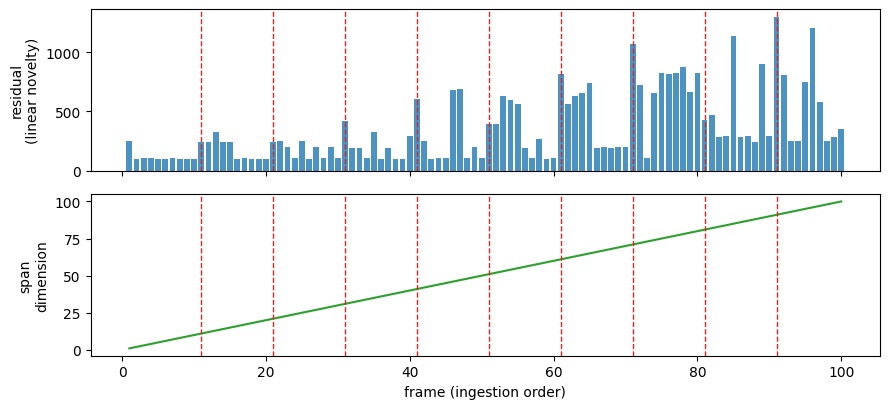

in-span push: in_span=True residual=0 rotation_count=0 generation 1 -> 1


In [4]:

window = BoolWindow(max_len=len(clip_sets))          # cap >= frames: growing span
stats = [window.push(s) for s in clip_sets]

novelty = np.array([s.residual for s in stats], dtype=float)
dim = np.array([s.dimension for s in stats], dtype=int)
rot = np.array([s.rotation_count for s in stats], dtype=int)
in_span = np.array([s.in_span for s in stats], dtype=bool)
cut_idx = [c - 1 for c in TRUE_CUTS]
in_idx = [i for i in range(len(stats)) if i not in set(cut_idx)]

print("dimension after %d frames: %d" % (len(stats), dim[-1]))
print("novelty at scene cuts : mean %.1f (min %d, max %d)" %
      (novelty[cut_idx].mean(), novelty[cut_idx].min(), novelty[cut_idx].max()))
print("novelty in-scene      : mean %.1f (min %d, max %d)" %
      (novelty[in_idx].mean(), novelty[in_idx].min(), novelty[in_idx].max()))
print("in-span pushes        : %d/%d" % (in_span.sum(), len(in_span)))
print("rotation_count > 0    : %d frames (max %d re-pivots)" % ((rot > 0).sum(), rot.max()))

print("\nframe  residual  in_span  dim   rotation_count  rotation_mass")
for i in range(8, 14):
    s = stats[i]
    print("%5d  %8d  %7s  %3d   %14d  %13d" %
          (i + 1, s.residual, s.in_span, s.dimension, s.rotation_count, s.rotation_mass))

fig, ax = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
t = np.arange(1, len(stats) + 1)
ax[0].bar(t, novelty, color="tab:blue", alpha=0.8)
ax[0].set_ylabel("residual\n(linear novelty)")
ax[1].plot(t, dim, color="tab:green")
ax[1].set_ylabel("span\ndimension")
ax[1].set_xlabel("frame (ingestion order)")
for a in ax:
    for c in TRUE_CUTS:
        a.axvline(c, color="tab:red", ls="--", lw=1)
plt.tight_layout()
plt.show()

# An in-span push (a repeated original) changes nothing: no extension, no
# rotation, no generation bump.
dup = BoolWindow(max_len=len(clip_sets))
dup.push(clip_sets[0])
gen_before = dup.generation()
s_dup = dup.push(clip_sets[0])
print("in-span push: in_span=%s residual=%d rotation_count=%d generation %d -> %d"
      % (s_dup.in_span, s_dup.residual, s_dup.rotation_count,
         gen_before, dup.generation()))


## §4 — Monotone basis vs. the visibility window

The basis is **monotone**: every pushed original is a permanent generator, so
`span(t) ⊆ span(t+1)` and a set that is representable stays representable.
`max_len` bounds only the **visibility window** — the recent originals the
ring exposes as context. Moving that window never drops a generator, so the
span dimension grows with the clip while `window_len` stays capped, and the
same sequence always reduces to the same pivots.

For contrast, `BoolWindow(..., evict_basis=True)` mirrors the legacy
`BoolWindow::windowed` mode, where the window *is* the generator set: there the
basis is rebuilt from the visible window and an evicted original falls out of
the span.

monotone ring, visibility cap=12:
  visible window : 1..12 (bounded by cap)
  generators     : 100 (total pushes)
  span dimension : 100 (grows with the clip)
  scene-cut novelty: monotone mean 612.6 | growing-window mean 612.6
frame 1 visible: False | still in span: True | residual: 0
same sequence -> same pivots: True
legacy windowed mode: dimension 12, frame 1 residual 247


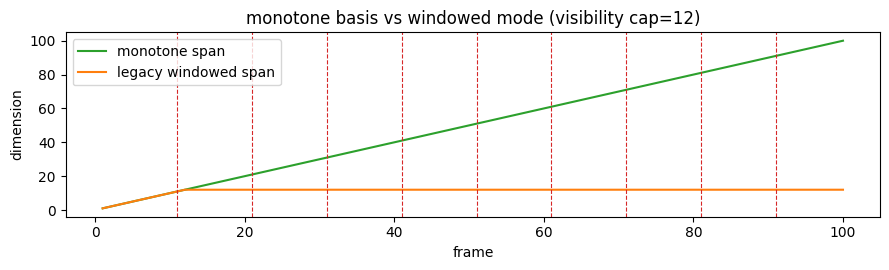

In [5]:

CAP = 12
ring = BoolWindow(CAP)                       # monotone basis + visibility cap
stats_m = []
vis_len, mono_dim = [], []
for s in clip_sets:
    stats_m.append(ring.push(s))
    vis_len.append(ring.window_len())
    mono_dim.append(ring.dimension())
mono_nov = np.array([s.residual for s in stats_m], dtype=float)

print("monotone ring, visibility cap=%d:" % CAP)
print("  visible window : %d..%d (bounded by cap)" % (min(vis_len), max(vis_len)))
print("  generators     : %d (total pushes)" % ring.total)
print("  span dimension : %d (grows with the clip)" % ring.dimension())
print("  scene-cut novelty: monotone mean %.1f | growing-window mean %.1f"
      % (mono_nov[cut_idx].mean(), novelty[cut_idx].mean()))

# The basis is monotone: an original stays representable after it leaves the
# visibility window.
old = clip_sets[0]
print("frame 1 visible:", old in list(ring.originals),
      "| still in span:", ring.coordinates(old) is not None,
      "| residual:", popcount(ring.residual(old)))

# Determinism: the same sequence gives the same pivots.
again = BoolWindow(CAP)
for s in clip_sets:
    again.push(s)
print("same sequence -> same pivots:", again.basis.pivots == ring.basis.pivots)

# Contrast: the legacy windowed mode drops the evicted generator.
legacy = BoolWindow(CAP, evict_basis=True)
leg_dim = []
for s in clip_sets:
    leg_dim.append(legacy.push(s).dimension)
print("legacy windowed mode: dimension %d, frame 1 residual %d"
      % (legacy.dimension(), popcount(legacy.residual(old))))

fig, ax = plt.subplots(figsize=(9, 2.8))
t = np.arange(1, len(clip_sets) + 1)
ax.plot(t, mono_dim, color="tab:green", label="monotone span")
ax.plot(t, leg_dim, color="tab:orange", label="legacy windowed span")
ax.set_ylabel("dimension"); ax.set_xlabel("frame")
ax.set_title("monotone basis vs windowed mode (visibility cap=%d)" % CAP)
ax.legend()
for c in TRUE_CUTS:
    ax.axvline(c, color="tab:red", ls="--", lw=0.8)
plt.tight_layout()
plt.show()


## §5 — `residual` / `coordinates`: evaluate a compound *without* inserting it

`coordinates(X)` returns the unique XOR of basis elements equal to `X`, or
`None` when `X` is outside the span; `residual(X)` is a remainder — it is
zero exactly when `X` is expressible from the monotone span.

Take two originals `A`, `B` from the clip (both in the span), then:

- `A Δ B` — **always** in the span (the span is closed under Δ);
- `A ∪ B`, `A ∩ B`, `A \ B` — usually outside, and mutually **congruent
  modulo the span**: since `A ∪ B = A Δ B Δ (A ∩ B)` and
  `A \ B = A Δ (A ∩ B)`, their pairwise differences are `A Δ B ∈ S`. They are
  therefore in-span together, or outside together.

The three remainders returned by `reduce` are representatives of that one
coset; here they happen to coincide, but §6 shows that is not an identity.

In [6]:

w = BoolWindow(max_len=len(clip_sets))
for s in clip_sets:
    w.push(s)
b = w.basis


def report(name, x):
    res = b.residual(x)
    coords = b.coordinates(x)
    print("%-26s |X|=%4d  in_span=%-5s  residual=%4d  coords=%s"
          % (name, popcount(x), coords is not None, popcount(res),
             "yes" if coords is not None else "None"))


A, B = clip_sets[0], clip_sets[1]
report("A = frame 1 (original)", A)
report("B = frame 2 (original)", B)
report("A Δ B  (ring addition)", symmetric_difference(A, B))
report("A ∪ B  (lattice join)", union(A, B))
report("A ∩ B  (lattice meet)", intersection(A, B))
report("A \\ B  (difference)", difference(A, B))

coords = b.coordinates(symmetric_difference(A, B))
print("\nA Δ B reconstructed from coordinates:",
      b.reconstruct(coords) == symmetric_difference(A, B))

# coset identity: the three compounds differ from the meet by span elements
print("(A∪B) Δ (A∩B) in span:", b.coordinates(union(A, B) ^ intersection(A, B)) is not None)
print("(A\\B) Δ (A∩B) in span:", b.coordinates(difference(A, B) ^ intersection(A, B)) is not None)
print("so A∪B, A∩B, A\\B are in-span together or outside together")
print("their reduce remainders (same coset, not canonical): %d, %d, %d"
      % (popcount(b.residual(union(A, B))), popcount(b.residual(intersection(A, B))),
         popcount(b.residual(difference(A, B)))))

# The compound is *discovered, not created*: pushing the meet as a new
# original extends the ring, after which it is representable.
w2 = BoolWindow(max_len=len(clip_sets) + 1)   # room, so nothing is evicted
for s in clip_sets:
    w2.push(s)
gen0, d0 = w2.generation(), w2.dimension()
w2.push(intersection(A, B))
print("\nafter pushing A∩B into the window:")
print("  dimension %d -> %d, generation %d -> %d"
      % (d0, w2.dimension(), gen0, w2.generation()))
print("  now coordinates(A∩B) is:", w2.coordinates(intersection(A, B)) is not None)

A = frame 1 (original)     |X|= 247  in_span=True   residual=   0  coords=yes
B = frame 2 (original)     |X|= 240  in_span=True   residual=   0  coords=yes
A Δ B  (ring addition)     |X|=  97  in_span=True   residual=   0  coords=yes
A ∪ B  (lattice join)      |X|= 292  in_span=False  residual=  53  coords=None
A ∩ B  (lattice meet)      |X|= 195  in_span=False  residual=  53  coords=None
A \ B  (difference)        |X|=  52  in_span=False  residual=  53  coords=None

A Δ B reconstructed from coordinates: True
(A∪B) Δ (A∩B) in span: True
(A\B) Δ (A∩B) in span: True
so A∪B, A∩B, A\B are in-span together or outside together
their reduce remainders (same coset, not canonical): 53, 53, 53

after pushing A∩B into the window:
  dimension 100 -> 101, generation 100 -> 101
  now coordinates(A∩B) is: True



## §6 — Representation constraints: what the ring can and cannot express

The span `S = span_GF(2)(originals)` is a **vector subspace**, hence
closed under `Δ` and linear combinations — but it is *not* a lattice ideal.

For `A, B ∈ S`, using distributivity of `∩` over `Δ`:

```text
A ∪ B = A Δ B Δ (A ∩ B)   ->   A∪B ∈ S  ⟺  A∩B ∈ S
A \ B = A Δ (A ∩ B)       ->   A\B ∈ S  ⟺  A∩B ∈ S
A Δ B = (A \ B) ∪ (B \ A) ->   AΔB ∈ S  always
```

So `A∪B`, `A∩B`, `A\B` are pairwise congruent modulo `S`: they share one
coset, and membership in `S` is a coset property. Exactly one lattice
operation carries new information: the **meet**. Because the span is
monotone, a compound that is outside at `t` can become representable once
later originals grow the span; pushing it as an original makes that permanent.

A general expression built from in-span sets with ∪, ∩, \ is in `S` iff its
meet content is in `S`; the exact algorithmic test for any set `X` is

```text
X ∈ S   ⟺   residual(X) = ∅   ⟺   coordinates(X) is not None
```

**Careful with the remainder.** `reduce` is deterministic given the generator sequence,
but its remainder is *a* representative of the coset `X + S`, not a canonical
one: the basis is row-echelon (distinct leading bits) rather than fully
reduced, and `reduce` stops at the first non-pivot lowest bit. Congruent sets
can therefore return different remainders, and a remainder may still contain
a pivot bit. The invariant is the coset; the zero test is what decides
representability.

### Structural characterization

`S` is closed under `∩` (equivalently under `∪` and `\`) **iff `S` admits a
pairwise-disjoint GF(2) basis**. Then `S` is exactly the family of unions of
the blocks of a partition — a Boolean subalgebra. For generic HLLSets this
essentially never happens: the originals share hash bits without a disjoint
atom structure, and the lattice they generate has up to `2^n` atoms while the
ring has at most `n` dimensions. The ring is a **lossy linear projection of
the lattice**, and the residual is the measurable error of that projection.

In [7]:

# ── Structural criterion on small, unambiguous molecules ───────────────────
def span_members(basis):
    mem = [0]
    for x in basis.basis:
        mem += [m ^ x for m in mem]
    return mem


def meet_closed(basis):
    mem = span_members(basis)
    return all((x & y) in mem for x in mem for y in mem)


def has_disjoint_basis(basis):
    mem = [x for x in span_members(basis) if x]
    k = basis.dimension()
    for combo in itertools.combinations(mem, k):
        if any(x & y for x, y in itertools.combinations(combo, 2)):
            continue
        cand = BoolBasis()
        for x in combo:
            cand.insert(x)
        if cand.dimension() == k:
            return True
    return False


def molecule(name, sets, width=4):
    basis = BoolBasis()
    for s in sets:
        basis.insert(s)
    bits = [format(x, "0%db" % width) for x in span_members(basis)]
    print("%-22s dim=%d  meet_closed=%-5s  disjoint_basis=%-5s  S=%s"
          % (name, basis.dimension(), meet_closed(basis),
             has_disjoint_basis(basis), bits))


molecule("disjoint {a,b}", [0b0011, 0b1100])
molecule("nested {B<=A}", [0b1111, 0b0011])
molecule("overlap u,v", [0b011, 0b110])
molecule("chain u,v,w", [0b0011, 0b0110, 0b1100])

# the criterion is not a coincidence
random.seed(7)
agree = total = 0
for _ in range(400):
    basis = BoolBasis()
    for _ in range(random.randint(2, 3)):
        basis.insert(random.getrandbits(10) | 1)
    if basis.dimension() < 2:
        continue
    total += 1
    agree += meet_closed(basis) == has_disjoint_basis(basis)
print("\nmeet_closed == has_disjoint_basis on %d random spans: %d/%d"
      % (total, agree, total))

disjoint {a,b}         dim=2  meet_closed=True   disjoint_basis=True   S=['0000', '0011', '1100', '1111']
nested {B<=A}          dim=2  meet_closed=True   disjoint_basis=True   S=['0000', '0011', '1100', '1111']
overlap u,v            dim=2  meet_closed=False  disjoint_basis=False  S=['0000', '0101', '0110', '0011']
chain u,v,w            dim=3  meet_closed=False  disjoint_basis=False  S=['0000', '1001', '1010', '0011', '1100', '0101', '0110', '1111']

meet_closed == has_disjoint_basis on 399 random spans: 399/399


In [8]:

# ── Empirical: how often do lattice compounds stay in a real HLLSet span? ──
random.seed(0)
pairs = [(random.randrange(len(clip_sets)), random.randrange(len(clip_sets)))
         for _ in range(400)]
pairs = [(i, j) for i, j in pairs if i != j]

for name, op in [("Δ", symmetric_difference), ("∩", intersection),
                 ("∪", union), ("\\", difference)]:
    hits = sum(1 for i, j in pairs
               if b.coordinates(op(clip_sets[i], clip_sets[j])) is not None)
    print("compound %-2s in span: %3d/%d (%.1f%%)"
          % (name, hits, len(pairs), 100.0 * hits / len(pairs)))

coset = sum(1 for i, j in pairs
            if b.coordinates(union(clip_sets[i], clip_sets[j])
                             ^ intersection(clip_sets[i], clip_sets[j])) is not None
            and b.coordinates(difference(clip_sets[i], clip_sets[j])
                              ^ intersection(clip_sets[i], clip_sets[j])) is not None)
print("∪, ∩, \\ pairwise congruent mod span: %d/%d pairs" % (coset, len(pairs)))

equal = sum(1 for i, j in pairs
            if popcount(b.residual(union(clip_sets[i], clip_sets[j])))
            == popcount(b.residual(intersection(clip_sets[i], clip_sets[j])))
            == popcount(b.residual(difference(clip_sets[i], clip_sets[j]))))
print("but the *reduce remainders* agree in popcount only %d/%d times — the"
      % (equal, len(pairs)))
print("remainder is a coset representative, not a canonical one")

# Constructed special cases that ARE representable.
nested = [clip_base[0], clip_sets[0]]          # base ⊆ full frame
disjoint = [hllset([f"x{j}" for j in range(20)]),
            hllset([f"y{j}" for j in range(20)])]
for name, (X, Y) in [("nested A⊆B", nested), ("bit-disjoint", disjoint)]:
    t = BoolBasis()
    for s in (X, Y):
        t.insert(s)
    print("\n%s:" % name)
    print("  A ∩ B in span:", t.coordinates(intersection(X, Y)) is not None,
          "| A ∪ B in span:", t.coordinates(union(X, Y)) is not None,
          "| A \\ B in span:", t.coordinates(difference(X, Y)) is not None,
          "| A Δ B in span:", t.coordinates(symmetric_difference(X, Y)) is not None)

compound Δ  in span: 394/394 (100.0%)
compound ∩  in span:   0/394 (0.0%)
compound ∪  in span:   0/394 (0.0%)
compound \  in span:   0/394 (0.0%)
∪, ∩, \ pairwise congruent mod span: 394/394 pairs


but the *reduce remainders* agree in popcount only 249/394 times — the


remainder is a coset representative, not a canonical one

nested A⊆B:
  A ∩ B in span: True | A ∪ B in span: True | A \ B in span: True | A Δ B in span: True

bit-disjoint:
  A ∩ B in span: True | A ∪ B in span: True | A \ B in span: True | A Δ B in span: True


In [9]:

# ── The remainder decomposes X exactly, but is not unique ──────────────────
# 1) exact decomposition using the actual window: first factor is in the span
sample = clip_sets[:40]
print("X Δ residual(X) is in the span:",
      all(b.coordinates(x ^ b.residual(x)) is not None for x in sample))
print("coordinates of in-span sets are unique (distinct leading bits):",
      all(b.reconstruct(b.coordinates(x)) == x for x in sample))
print("zero test decides representability:",
      all((b.coordinates(x) is not None) == (b.residual(x) == 0) for x in sample))

# 2) the remainder is not canonical — crafted small basis with a gap at bit 1
small = BoolBasis()
for s in [0b0001, 0b1100]:     # leading bits 0 and 2
    small.insert(s)
print("\nsmall basis:", [format(x, "04b") for x in small.basis],
      "pivots", small.pivots)
x = 0b0110                     # {1,2}
y = x ^ small.basis[1]         # {1,3}: congruent to x mod span
rx, ry = small.residual(x), small.residual(y)
print("x =", format(x, "04b"), " y =", format(y, "04b"),
      "| x Δ y in span:", small.coordinates(x ^ y) is not None)
print("residual(x) =", format(rx, "04b"), " residual(y) =", format(ry, "04b"),
      "-> different representatives of one coset")
print("residual(x) still contains pivot bit 2:", has_bit(rx, 2))
print("both decompose exactly:",
      small.coordinates(x ^ rx) is not None and small.coordinates(y ^ ry) is not None)

X Δ residual(X) is in the span: True
coordinates of in-span sets are unique (distinct leading bits): True
zero test decides representability: True

small basis: ['0001', '1100'] pivots [0, 2]
x = 0110  y = 1010 | x Δ y in span: True
residual(x) = 0110  residual(y) = 1010 -> different representatives of one coset
residual(x) still contains pivot bit 2: True
both decompose exactly: True



## §7 — The production implementation

The notebook mirror is checked against the crate's own tests, and
`ewm-scene sidecar` runs the same **monotone** ring on the **production ingest
morphism** (`μ_ng`, the multi-seed n-gram projection). The two morphisms give
different sets and different novelty scales, but the ring algebra is the same:
the span dimension grows with the clip (`1..100` here, not bounded by the
visibility cap) and rotation counts re-pivotings.

The monotone residual is *cumulative* novelty — measured against everything
seen so far — so in-scene drift keeps it high and the scene-cut separation is
weaker than the legacy windowed series. That is the trade being made: the
visibility window bounds the context the ring *exposes*, while the span keeps
every generator. `BoolWindow::windowed(cap)` reproduces the earlier
scene-bounded novelty when that signal is wanted.

In [10]:

work = pathlib.Path("/tmp/ewm_boolring_nb")
work.mkdir(parents=True, exist_ok=True)
frames_path = work / "frames.jsonl"
with open(frames_path, "w") as fh:
    for i, toks in enumerate(clip_tokens):
        fh.write(json.dumps({"id": i + 1, "tokens": toks}) + "\n")

HAVE_SCENE = EWM_SCENE.exists()
if not HAVE_SCENE:
    try:
        subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"], cwd=ROOT, check=True)
        HAVE_SCENE = True
    except Exception as exc:                     # offline / no toolchain
        print("ewm-scene unavailable:", exc)

if HAVE_SCENE:
    def ewm_scene(*args):
        r = subprocess.run([str(EWM_SCENE), *args], capture_output=True, text=True, timeout=600)
        if r.returncode != 0:
            raise RuntimeError(r.stderr[-800:])
        return json.loads(r.stdout)

    ring = ewm_scene("sidecar", str(frames_path), "--cap", "12")
    frames = ring["frames"]
    cut_nov = [frames[c - 1]["residual"] for c in TRUE_CUTS]
    in_nov = [f["residual"] for c, f in enumerate(frames) if (c + 1) not in set(TRUE_CUTS)]
    print("ewm-scene sidecar (μ_ng, cap=12):")
    print("  scene-cut residual : mean %.1f" % (sum(cut_nov) / len(cut_nov)))
    print("  in-scene residual  : mean %.1f" % (sum(in_nov) / len(in_nov)))
    print("  dimension range    : %d..%d"
          % (min(f["dim"] for f in frames), max(f["dim"] for f in frames)))
    print("  rotation_count > 0 : %d frames" % sum(1 for f in frames if f["rotation_count"] > 0))

    try:
        tests = subprocess.run(["cargo", "test", "-q", "-p", "ewm-boolring"],
                               cwd=ROOT, capture_output=True, text=True, timeout=900)
        out = (tests.stdout + tests.stderr).strip().splitlines()
        print("\ncargo test -p ewm-boolring:", "PASS" if tests.returncode == 0 else "FAIL")
        for line in out:
            if "test result" in line:
                print("  " + line.strip())
    except Exception as exc:
        print("cargo test skipped:", exc)

ewm-scene sidecar (μ_ng, cap=12):
  scene-cut residual : mean 1446.8
  in-scene residual  : mean 1069.3
  dimension range    : 1..100
  rotation_count > 0 : 77 frames

cargo test -p ewm-boolring: PASS
  test result: ok. 15 passed; 0 failed; 0 ignored; 0 measured; 0 filtered out; finished in 0.00s
  test result: ok. 0 passed; 0 failed; 0 ignored; 0 measured; 0 filtered out; finished in 0.00s



## Summary

**What `BoolWindow` is.** A **monotone generator basis** over *original*
HLLSets in ingestion order, plus a bounded **visibility window** of the recent
originals. `push` is one Gaussian step (residual = linear novelty, dimension,
rotation_count / rotation_mass); moving the visibility window never drops a
generator, so `span(t) ⊆ span(t+1)` and a representable set stays
representable. `residual` and `coordinates` evaluate any set against the span
without inserting it. The legacy `BoolWindow::windowed(cap)` mode keeps the old
windowed-basis behavior for comparison. Because the generator sequence is
fixed, the basis is deterministic — comparable across the run.

**Representation constraints.** An HLLSet built by lattice operations from
in-span sets is exactly an XOR of ring base HLLSets only under a precise
condition:

| operation | in the ring span `S`? |
| - | - |
| `A Δ B` | **always** |
| `A ∪ B` | iff `A ∩ B ∈ S` |
| `A \ B` | iff `A ∩ B ∈ S` |
| `A ∩ B` | the obstruction — usually not in `S` |

`S` is closed under `∩` (hence `∪`, `\`) iff it has a pairwise-disjoint
basis, i.e. iff it is a Boolean subalgebra — essentially never true for
generic HLLSets. Otherwise there is **no exact representation**: you can only
record `X = (X Δ residual(X)) Δ residual(X)`, where the first factor is in
the span and the second is a remainder of the coset `X + S`. The remainder is
deterministic but not canonical (congruent sets may return different
remainders), so the invariant object is the coset, and `residual(X) = ∅` is
the exact representability test. To make a compound exactly representable,
**discover a new node**: push it as an original and the monotone span grows to
include it permanently.